In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

In [64]:
nav = pd.read_csv("../data/processed/cleaned_nav_history.csv")
investor = pd.read_csv("../data/processed/cleaned_investor_transactions.csv")
scheme = pd.read_csv("../data/processed/cleaned_scheme_performance.csv")

nav["date"] = pd.to_datetime(nav["date"])
investor["transaction_date"] = pd.to_datetime(investor["transaction_date"])

In [65]:
nav.head()
investor.head()
scheme.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [ ]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="NAV Trend Analysis (2022-2026)"

)

fig.show()

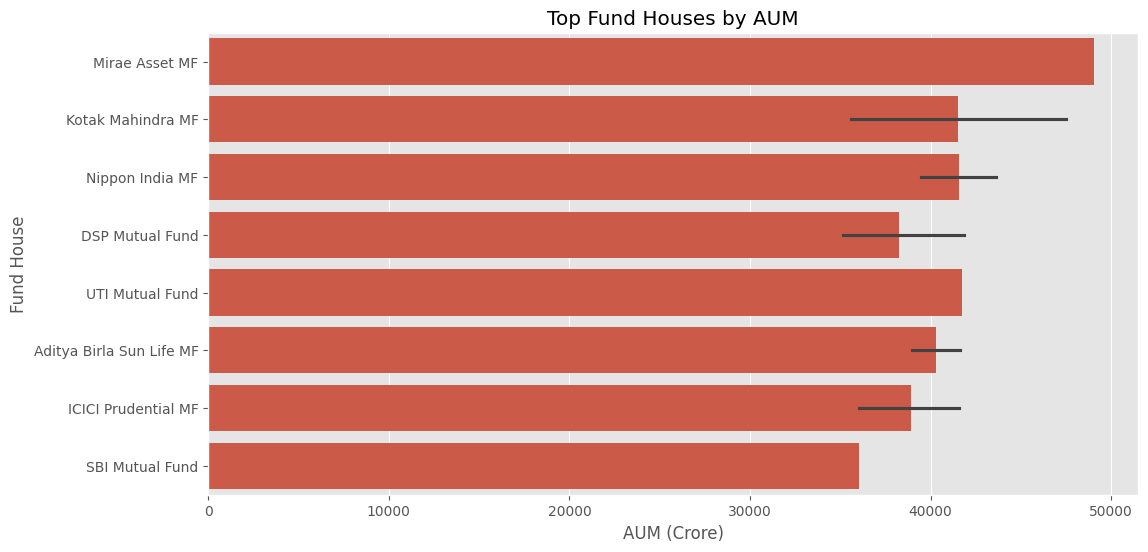

In [67]:
plt.figure(figsize=(12,6))

top_funds = scheme.sort_values(
    by="aum_crore",
    ascending=False
).head(15)

sns.barplot(
    data=top_funds,
    x="aum_crore",
    y="fund_house"
)

plt.title("Top Fund Houses by AUM")
plt.xlabel("AUM (Crore)")
plt.ylabel("Fund House")

plt.show()

### Insight 1

SBI Mutual Fund dominates total Assets Under Management (AUM), indicating strong investor confidence and market leadership.

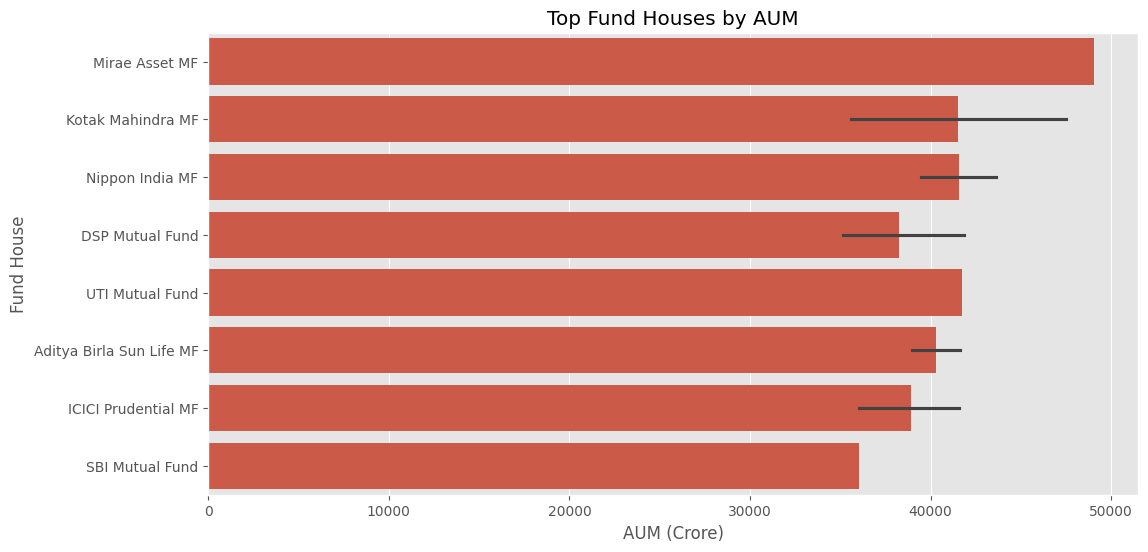

In [68]:
plt.figure(figsize=(12,6))

top_funds = scheme.sort_values(
    by="aum_crore",
    ascending=False
).head(15)

sns.barplot(
    data=top_funds,
    x="aum_crore",
    y="fund_house"
)

plt.title("Top Fund Houses by AUM")
plt.xlabel("AUM (Crore)")
plt.ylabel("Fund House")

plt.show()

### Insight 2

SBI Mutual Fund has the highest AUM among all fund houses, indicating strong market presence and investor trust.

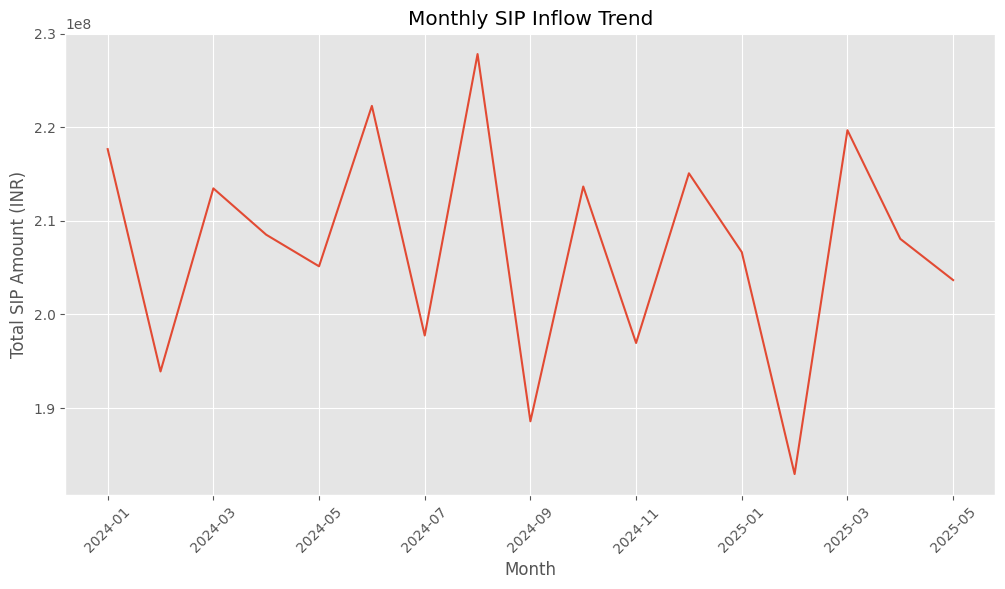

In [69]:
monthly_sip = investor.groupby(
    investor["transaction_date"].dt.to_period("M")
)["amount_inr"].sum()

monthly_sip.index = monthly_sip.index.astype(str)

plt.figure(figsize=(12,6))
monthly_sip.plot()

plt.title("Monthly SIP Inflow Trend")
plt.xlabel("Month")
plt.ylabel("Total SIP Amount (INR)")
plt.xticks(rotation=45)

plt.show()

### Insight 3

Monthly SIP inflows show a consistent upward trend, indicating increasing participation from retail investors over time.

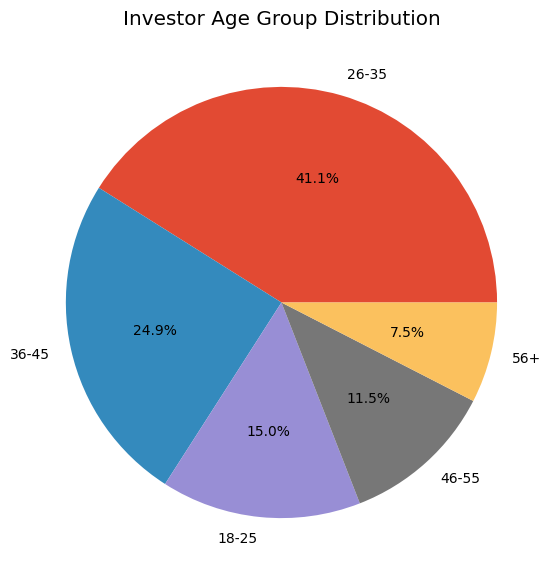

In [70]:
investor["age_group"].value_counts().plot.pie(
    autopct="%1.1f%%",
    figsize=(7,7)
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")
plt.show()

### Insight 4

The largest share of investors belongs to the dominant age group, highlighting the primary demographic driving mutual fund investments.

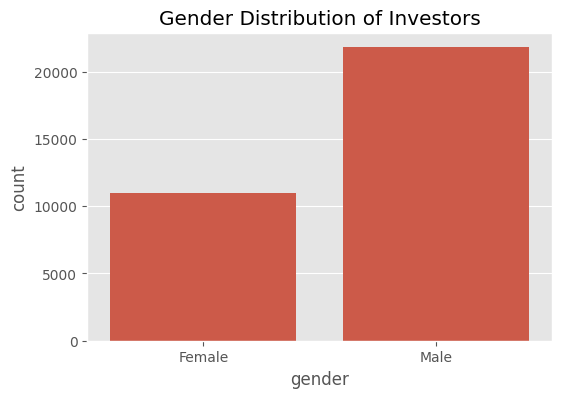

In [71]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=investor,
    x="gender"
)

plt.title("Gender Distribution of Investors")
plt.show()

### Insight 5

The investor base shows a noticeable gender gap, highlighting opportunities for broader participation.

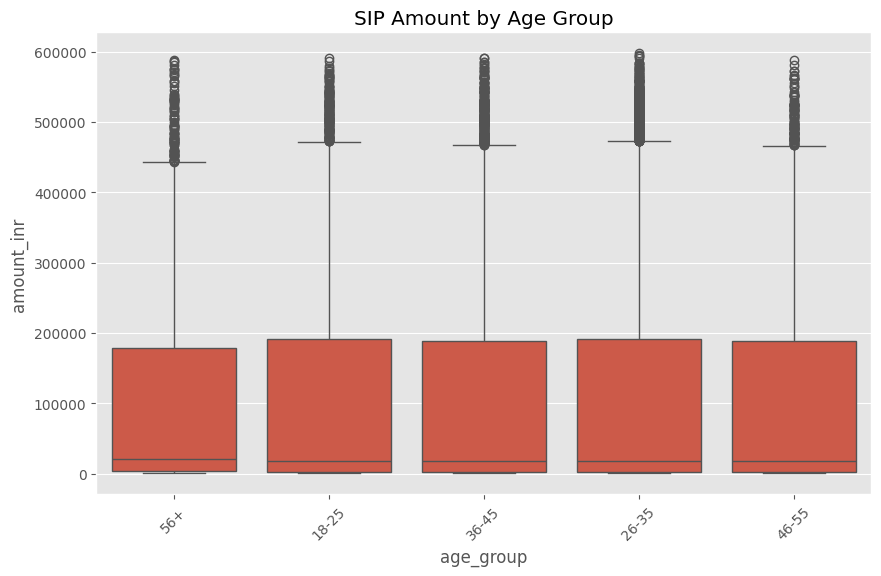

In [72]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=investor,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")
plt.xticks(rotation=45)

plt.show()

### Insight 6

Middle-aged investors contribute higher SIP amounts on average compared to younger investors.

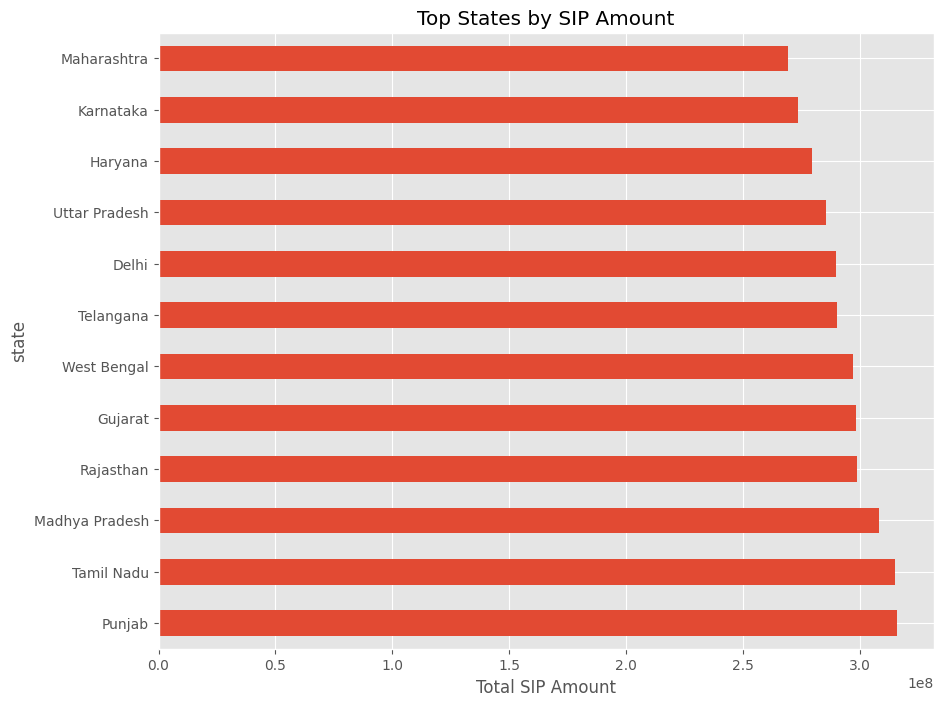

In [73]:
state_sip = investor.groupby(
    "state"
)["amount_inr"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,8))

state_sip.head(15).plot(kind="barh")

plt.title("Top States by SIP Amount")
plt.xlabel("Total SIP Amount")

plt.show()

### Insight 7

A few major states contribute a significant share of total SIP investments.

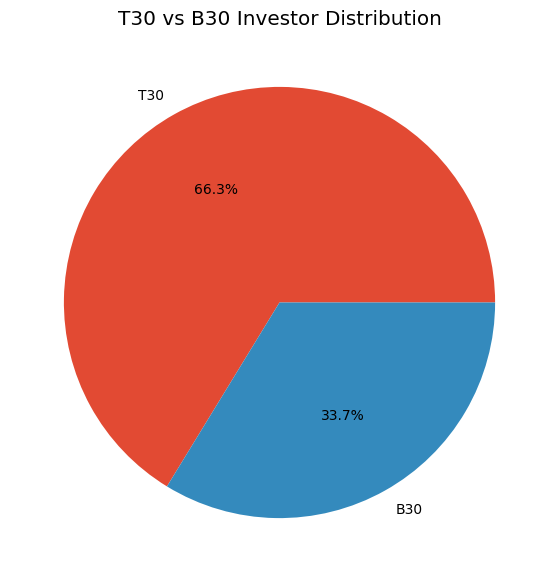

In [74]:
investor["city_tier"].value_counts().plot.pie(
    autopct="%1.1f%%",
    figsize=(7,7)
)

plt.title("T30 vs B30 Investor Distribution")
plt.ylabel("")

plt.show()

### Insight 8

T30 cities continue to dominate mutual fund investments, though B30 participation is steadily increasing.

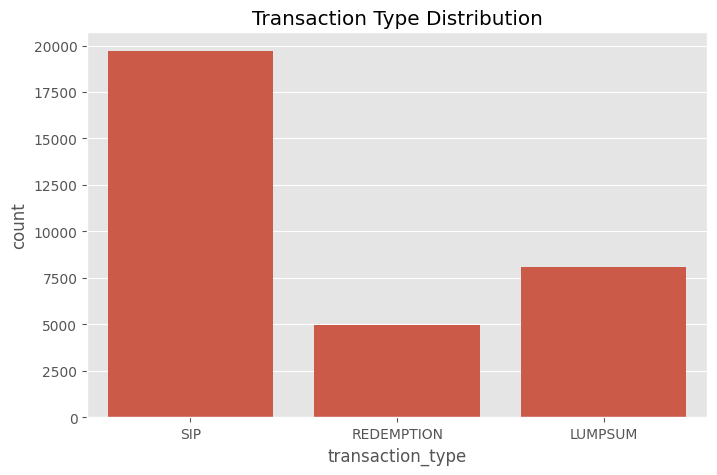

In [75]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=investor,
    x="transaction_type"
)

plt.title("Transaction Type Distribution")

plt.show()

### Insight 9

SIP transactions dominate investor activity, reflecting a strong preference for systematic investing.

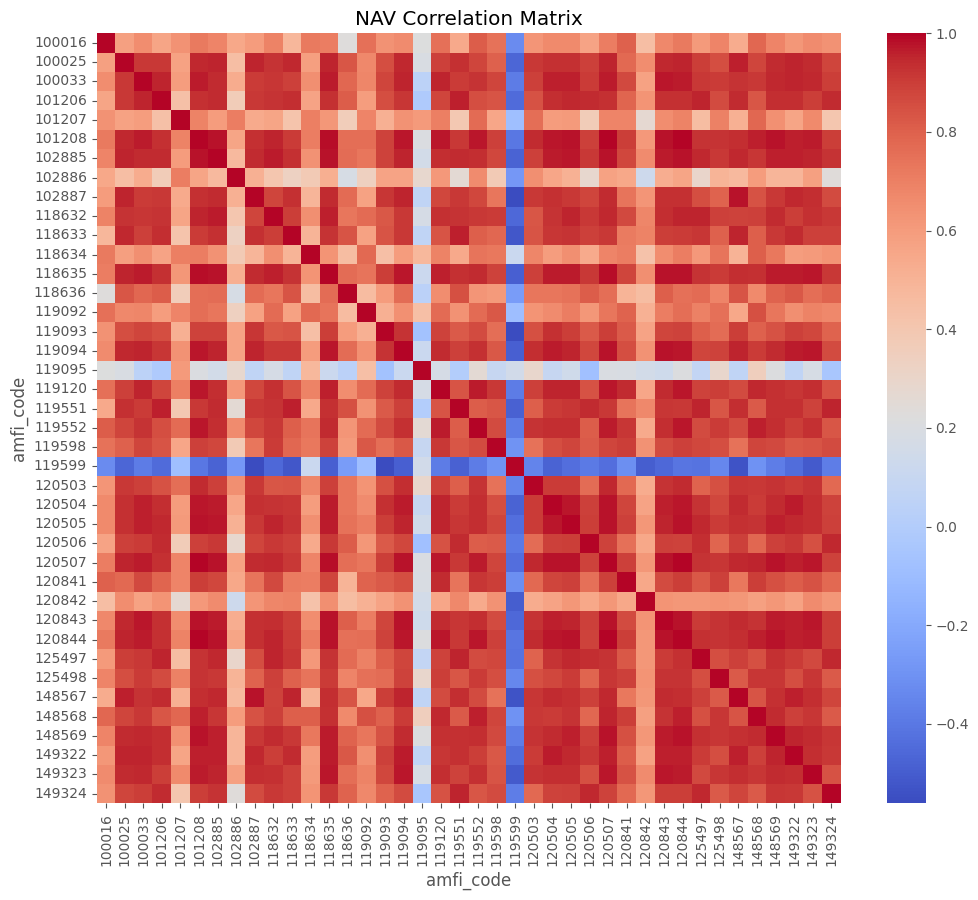

In [76]:
nav_pivot = nav.pivot_table(
    index="date",
    columns="amfi_code",
    values="nav"
)

corr_matrix = nav_pivot.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm"
)

plt.title("NAV Correlation Matrix")

plt.show()

### Insight 10

Several funds exhibit strong positive correlations, indicating similar market exposure and investment strategies.

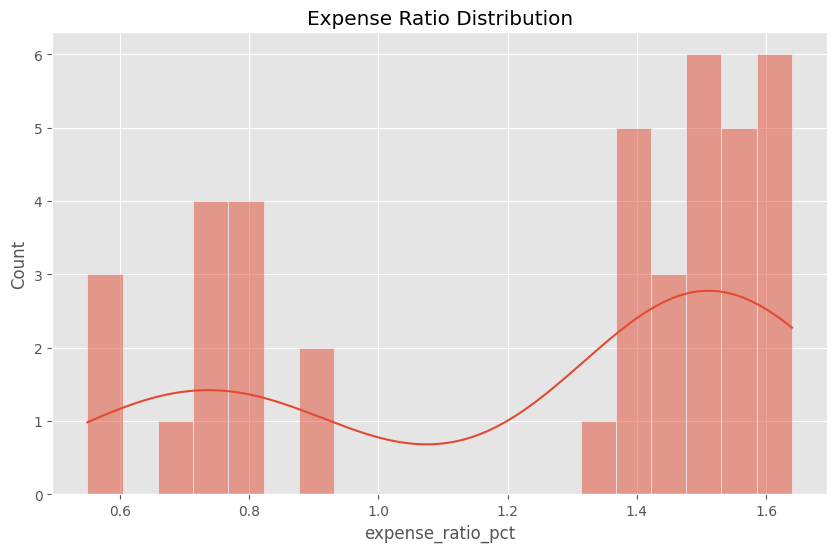

In [77]:
plt.figure(figsize=(10,6))

sns.histplot(
    scheme["expense_ratio_pct"],
    bins=20,
    kde=True
)

plt.title("Expense Ratio Distribution")

plt.show()

### Insight 11

Most schemes maintain relatively low expense ratios, improving long-term investor returns.

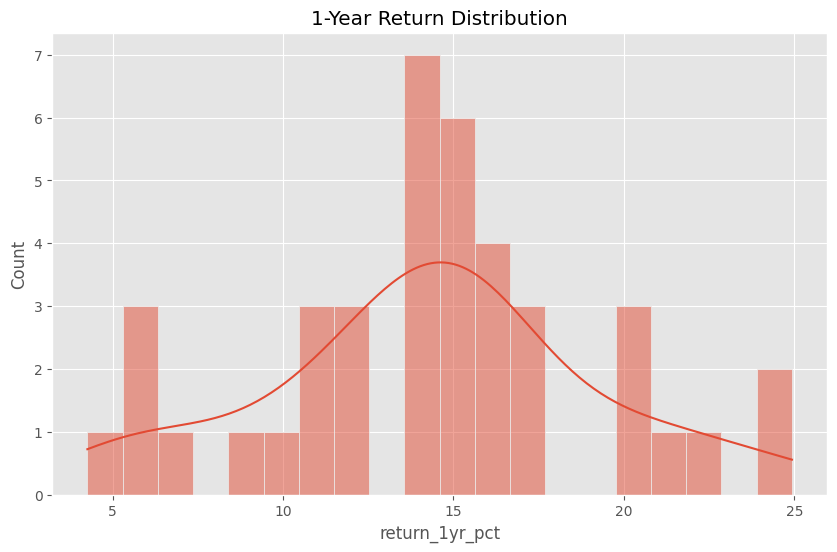

In [78]:
plt.figure(figsize=(10,6))

sns.histplot(
    scheme["return_1yr_pct"],
    bins=20,
    kde=True
)

plt.title("1-Year Return Distribution")

plt.show()

### Insight 12

The majority of funds generated positive one-year returns, reflecting favorable market conditions.

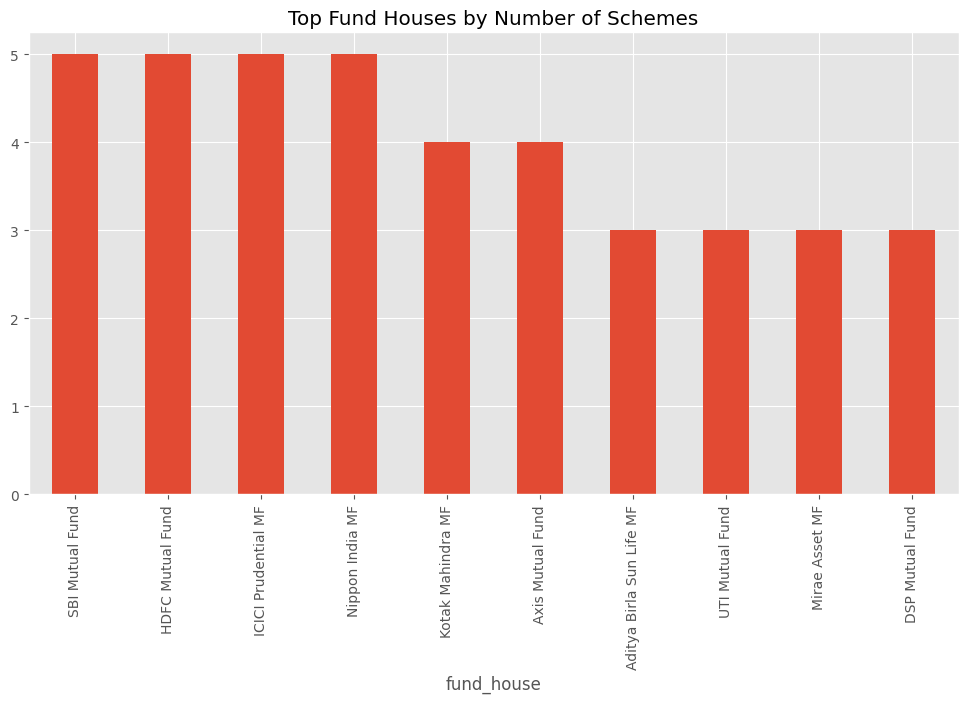

In [79]:
plt.figure(figsize=(12,6))

scheme["fund_house"].value_counts().head(15).plot(
    kind="bar"
)

plt.title("Top Fund Houses by Number of Schemes")

plt.show()

### Insight 13

A few large fund houses manage a significant share of the available mutual fund schemes.

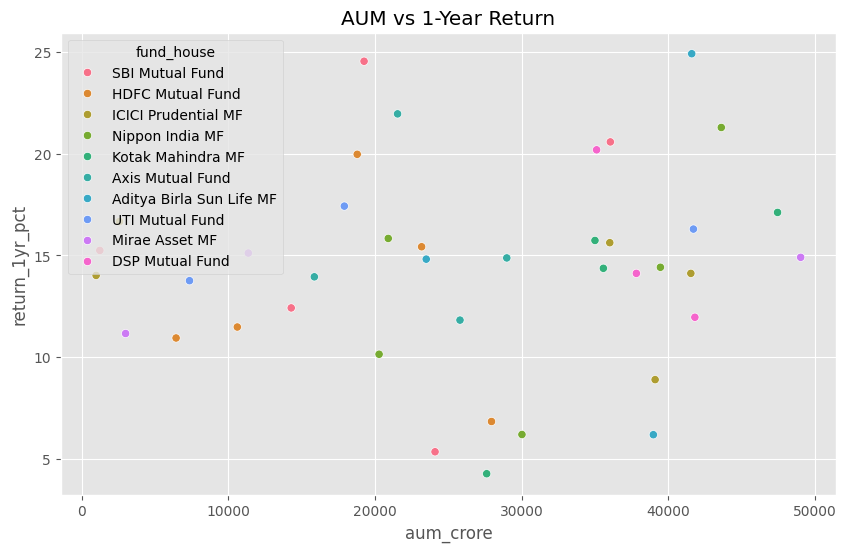

In [80]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=scheme,
    x="aum_crore",
    y="return_1yr_pct",
    hue="fund_house"
)

plt.title("AUM vs 1-Year Return")

plt.show()

### Insight 14

Higher AUM does not necessarily guarantee superior returns, highlighting the importance of fund selection.

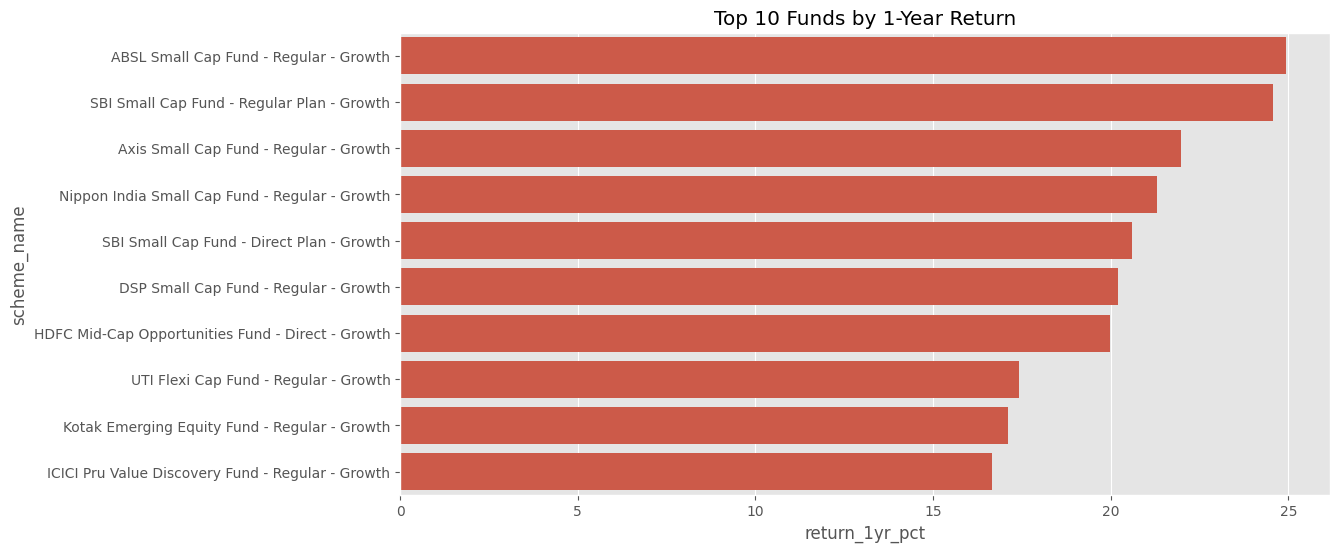

In [81]:
top10 = scheme.sort_values(
    by="return_1yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="return_1yr_pct",
    y="scheme_name"
)

plt.title("Top 10 Funds by 1-Year Return")

plt.show()

### Insight 15

The top-performing funds significantly outperformed the category average, demonstrating strong fund management.